# Single Pendulum

Simulating a simple pendulum using Euler's method. The system is a point mass on a massless rigid rod, swinging under gravity with no damping or driving forces. The equations of motions (EoM) are derived via the lagrangian method (see "src/dynamics/systems/single_pendulum.py" for implementation).



In [2]:
import numpy as np
import matplotlib.pyplot as plt

from dynamics.systems.single_pendulum import SinglePendulum
import dynamics.solver as slv

In [3]:
# System parameters
m = 1.0 # [kg]
L = 1.0 # [m]

pendulum = SinglePendulum(m, L)

# Starting state
theta0 = 0.5 # [rad]
omega0 = 0.0 # [rad/s]
y0 = np.array([theta0, omega0])

# Simulation time parameters
t0 = 0.0
t_end = 20.0
dt = 0.001

In [ ]:
# Finding number of steps and state variables
n_step = int((t_end - t0) / dt) + 1
n_state = np.size(y0)

# Allocating memory for plotting
t_values = np.zeros([n_step])
y_values = np.zeros([n_step, n_state])

t_values[0] = t0
y_values[0, :] = y0

# Assigning initial conditions
t = t0
y = y0.copy()

# Solving the system and saving every step
for i in range(1, n_step):
    y = slv.euler(pendulum.derivatives, t, y, dt)
    t = t + dt 
    t_values[i] = t
    y_values[i, :] = y


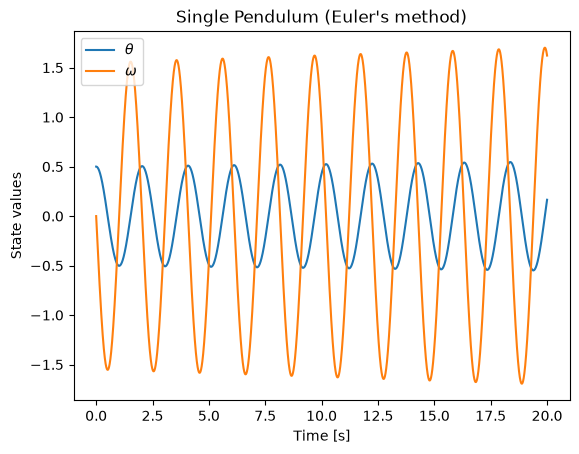

In [ ]:
labels = pendulum.state_labels()
greek_map = {"theta": r"$\theta$", "omega": r"$\omega$"}


plt.figure()
for i, k in enumerate(labels):
    plt.plot(t_values, y_values[:, i], label = greek_map.get(k, k))

plt.xlabel("Time [s]")
plt.ylabel("State values")
plt.legend()
plt.title("Single Pendulum (Euler's method)")
plt.show()